# Purged validation: follow the label's information

A learned risky-asset budget might use next-month relative returns as a target. Adjacent labels can share returns even when their decision dates differ. This chapter constructs a small information timeline, verifies purging and embargo independently, and fits one fixed model with training-only transformations.

All observations are original numerical illustrations. This is an information-boundary demonstration, not a return-prediction result. [Chapter discussion and sources](README.md) · [Research map](../../README.md)

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "research/validation.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from research.validation import purged_train_indices

SEED = 20260919
raw_log_returns = np.random.default_rng(SEED).normal(0, 0.01, 47)
starts = np.arange(6, 42)       # 36 decision dates, in integer bar positions
ends = starts + 5              # Forward five-bar label, known at its end
held_out = np.arange(14, 20)    # Six adjacent decision rows
EMBARGO = 3                    # Bars after the end of each test label


def feature_and_label_arrays(raw):
    # Both features use information available at the decision close.
    features = np.array([[raw[s - 3:s + 1].mean(), raw[s]] for s in starts])
    labels = np.array([raw[s + 1:e + 1].sum() for s, e in zip(starts, ends)])
    return features, labels


features, labels = feature_and_label_arrays(raw_log_returns)
naive = np.setdiff1d(np.arange(len(starts)), held_out)
purged = purged_train_indices(starts, ends, held_out)
train = purged_train_indices(starts, ends, held_out, embargo=EMBARGO)
print({"seed": SEED, "decisions": len(starts), "test_rows": len(held_out),
       "naive_training_rows": len(naive), "purged_training_rows": len(purged),
       "purged_and_embargoed_training_rows": len(train)})

{'seed': 20260919, 'decisions': 36, 'test_rows': 6, 'naive_training_rows': 30, 'purged_training_rows': 20, 'purged_and_embargoed_training_rows': 17}


## Audit intervals before fitting

Each label has the closed information interval $[s_i,e_i]$. Shared endpoints are conservatively treated as overlap, even though the constructed log-return sum starts at $s_i+1$. The embargo blocks starts in $(e_j,e_j+3]$ after each test label; applying the union handles both adjacent and disjoint held-out intervals. It does not fill unrelated gaps between separated test intervals.

Here, the four-bar feature lookback is the reason for the three-bar buffer. The first eligible future training feature begins after all held-out information. Other features or longer dependence would require a different declared design.

In [2]:
protected_bars = set()
for j in held_out:
    protected_bars.update(range(int(starts[j]), int(ends[j]) + EMBARGO + 1))
oracle_train = [i for i in range(len(starts))
                if set(range(int(starts[i]), int(ends[i]) + 1)).isdisjoint(protected_bars)]
np.testing.assert_array_equal(train, oracle_train)
np.testing.assert_array_equal(train, np.r_[0:9, 28:36])

status = np.full(len(starts), "Purged", dtype=object)
status[purged] = "Embargoed"
status[train] = "Training"
status[held_out] = "Test"
timeline = pd.DataFrame({"decision_bar": starts, "label_end": ends, "status": status})
display(timeline)
print("Independent discrete information-set check passed for every decision.")

,decision_bar,label_end,status
0,6,11,Training
1,7,12,Training
2,8,13,Training
3,9,14,Training
4,10,15,Training
5,11,16,Training
6,12,17,Training
7,13,18,Training
8,14,19,Training
9,15,20,Purged


Independent discrete information-set check passed for every decision.


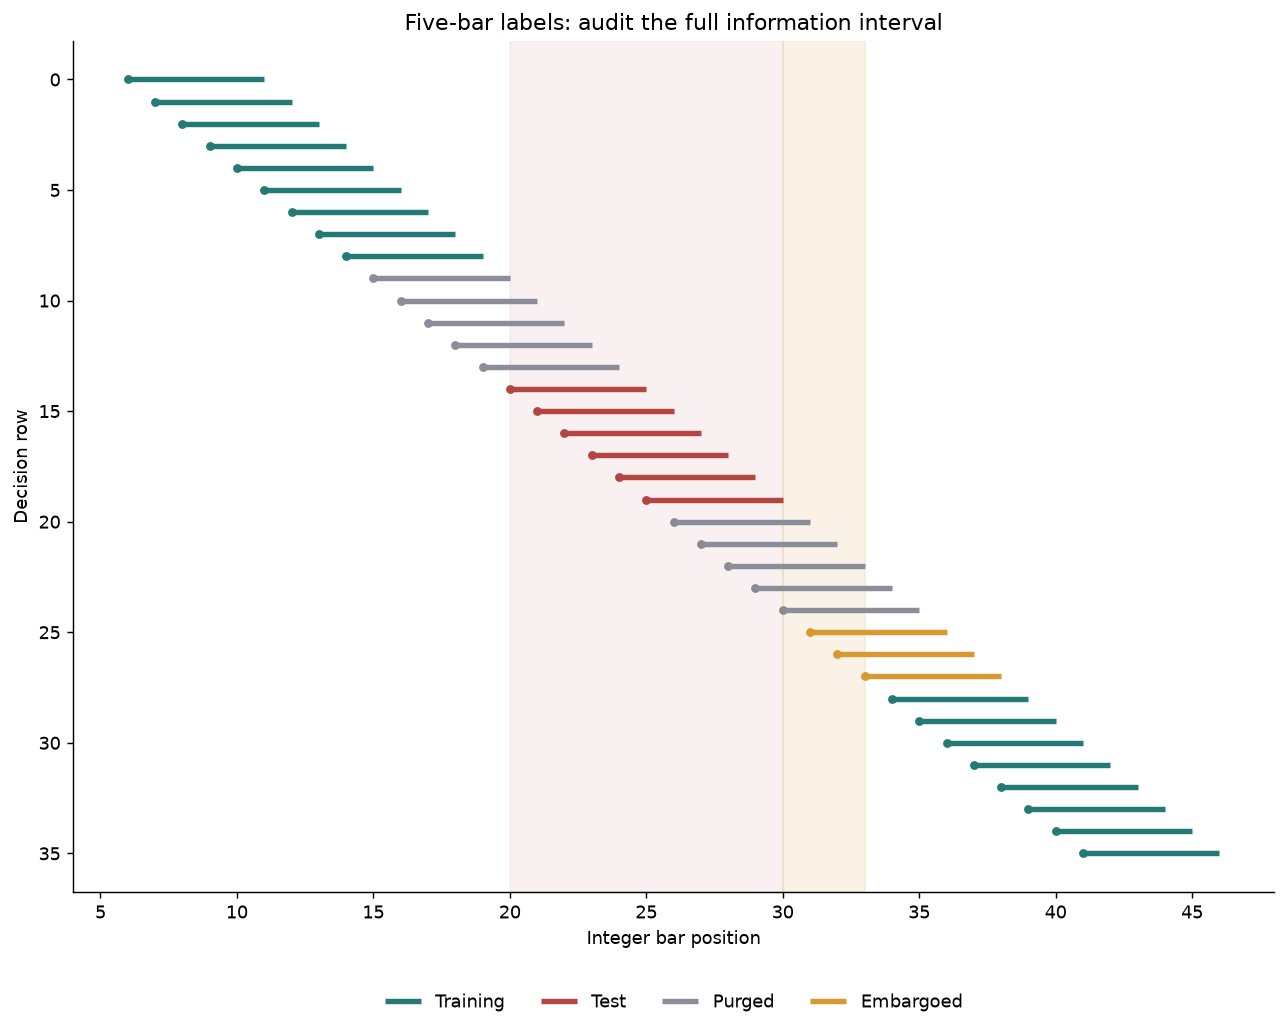

In [3]:
colors = {"Training": "#237a75", "Test": "#b34543", "Purged": "#8b8e98", "Embargoed": "#d89832"}
fig, ax = plt.subplots(figsize=(10, 8))
for label, color in colors.items():
    rows = np.flatnonzero(status == label)
    ax.hlines(rows, starts[rows], ends[rows], color=color, linewidth=3, label=label)
    ax.scatter(starts[rows], rows, color=color, s=15)
ax.axvspan(starts[held_out].min(), ends[held_out].max(), color=colors["Test"], alpha=0.07)
ax.axvspan(ends[held_out].max(), ends[held_out].max() + EMBARGO,
           color=colors["Embargoed"], alpha=0.12)
ax.invert_yaxis()
ax.set(xlabel="Integer bar position", ylabel="Decision row",
       title="Five-bar labels: audit the full information interval")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.10), frameon=False)
fig.tight_layout()
plt.show()

## Change held-out information and check the fitted model

The scaler and ridge regression see only retained training observations. Ridge's penalty is fixed at 1; there is no hyperparameter contest. Perturbing the raw returns inside the held-out information interval must leave the retained training arrays and fitted model unchanged in this example. The same perturbation can affect the future features admitted by purging without this embargo.

A scaler fitted to the entire feature matrix also changes. That is a second leakage path: a correctly selected training index does not justify fitting preprocessing globally.

In [4]:
def fit_training_only(x, y, rows):
    scaler = StandardScaler().fit(x[rows])
    model = Ridge(alpha=1.0).fit(scaler.transform(x[rows]), y[rows])
    return scaler, model


scaler, model = fit_training_only(features, labels, train)
changed_returns = raw_log_returns.copy()
changed_returns[starts[held_out].min():ends[held_out].max() + 1] += 0.5
changed_features, changed_labels = feature_and_label_arrays(changed_returns)
changed_scaler, changed_model = fit_training_only(changed_features, changed_labels, train)
np.testing.assert_array_equal(features[train], changed_features[train])
np.testing.assert_array_equal(labels[train], changed_labels[train])
np.testing.assert_array_equal(scaler.mean_, changed_scaler.mean_)
np.testing.assert_allclose(model.coef_, changed_model.coef_, atol=0, rtol=0)
np.testing.assert_allclose(model.intercept_, changed_model.intercept_, atol=0, rtol=0)
assert not np.array_equal(features[purged], changed_features[purged])

all_rows_scaler = StandardScaler().fit(features)
changed_all_rows_scaler = StandardScaler().fit(changed_features)
assert not np.allclose(all_rows_scaler.mean_, changed_all_rows_scaler.mean_)
comparison = pd.DataFrame({
    "boundary": ["Retained training feature matrix", "Purging without embargo: feature matrix", "Scaler fitted to all rows"],
    "maximum absolute change": [np.max(np.abs(features[train] - changed_features[train])),
        np.max(np.abs(features[purged] - changed_features[purged])),
        np.max(np.abs(all_rows_scaler.mean_ - changed_all_rows_scaler.mean_))],
})
display(comparison)
print("Retained training labels, fitted coefficients and intercept are unchanged.")

,boundary,maximum absolute change
0,Retained training feature matrix,0.000000
1,Purging without embargo: feature matrix,0.375000
2,Scaler fitted to all rows,0.152778


Retained training labels, fitted coefficients and intercept are unchanged.


## Connect the split to portfolio research

The test fold sits inside the sample: some retained training rows occur later. This split studies generalization conditional on an information design; it is not a chronological trading path. A past-only experiment would additionally require every training label to finish before the evaluation decision. Purging cannot make later observations available earlier.

If tuning an allocation's lookback or covariance estimator, conduct that selection inside each outer training set. Scaling, feature selection and model fitting belong within each inner training fold. Then freeze the selected rule before evaluating the untouched outer fold. This notebook implements the split and one fixed training-only fit, not nested search or full CPCV.

For the existing risk-based ETF allocator, there are no supervised forward-return labels: its prior-only risk estimates and delayed ownership rules remain the relevant controls. Adding an ML return signal would introduce the additional label-horizon problem illustrated here. Neither a three-bar buffer nor purging guarantees independence for real persistent or changing financial processes.

Source: [López de Prado's author overview](https://www.quantresearch.org/Innovations.htm) and [*Advances in Financial Machine Learning*, Chapters 7, 9 and 12](https://www.wiley.com/en-us/Advances+in+Financial+Machine+Learning-p-9781119482086). Original implementation: [research/validation.py](../../research/validation.py).